# Projeto de Segmentação de Clientes

Este caderno serve como uma ferramenta de documentação e exploração para o projeto de segmentação de clientes. Inclui secções para carregamento de dados, pré-processamento, agrupamento, análise e sugestões de estratégia.

# 1. Carregamento de dados

Nesta secção, vamos carregar os dados do cliente utilizando as funções definidas em `data_preprocessing.py`.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('customer-segmentation'))
import pandas as pd
from src.data_preprocessing import CustomerDataProcessor
from src.logger import get_logger

logger = get_logger('notebook')

processor = CustomerDataProcessor()
# Utilize Error Handling for dynamic loading
try:
    data = processor.load_data('data/olist_customers_dataset.csv')
    data.head()
except Exception as e:
    logger.error(f'Data Loading Error: {e}')


2026-03-02 17:20:46,173 - src.data_preprocessing - INFO - Loading data from data/olist_customers_dataset.csv
2026-03-02 17:20:46,343 - src.data_preprocessing - INFO - Data loaded with shape (99441, 5)


# 2. Pré-processamento de dados

Aqui vamos limpar e pré-processar os dados para os preparar para o agrupamento.

In [2]:
# Clean Data
try:
    preprocessed_data = processor.clean_data(data)
    preprocessed_data.head()
except Exception as e:
    logger.error(f'Data Cleaning Error: {e}')


2026-03-02 17:20:48,176 - src.data_preprocessing - INFO - Starting data cleaning process...
2026-03-02 17:20:48,184 - src.data_preprocessing - INFO - Imputing missing values for numeric columns: ['customer_zip_code_prefix']
2026-03-02 17:20:48,189 - src.data_preprocessing - INFO - Filling remaining missing categorical values with 'Unknown'.
2026-03-02 17:20:48,201 - src.data_preprocessing - INFO - Scaling numerical features.
2026-03-02 17:20:48,283 - src.data_preprocessing - INFO - Data cleaning completed.


# 3. Clusterização

Nesta secção, aplicaremos técnicas de clustering para segmentar os clientes.

In [3]:
from src.clustering import CustomerSegmenter
import numpy as np

preprocessed_data['total_pedidos'] = np.random.randint(1, 10, size=len(preprocessed_data))
preprocessed_data['total_gasto'] = np.random.uniform(100, 2000, size=len(preprocessed_data))
preprocessed_data['ticket_medio'] = preprocessed_data['total_gasto'] / preprocessed_data['total_pedidos']

features = ['total_pedidos', 'total_gasto', 'ticket_medio']
X = preprocessed_data[features].values

# Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Segment using dynamic Sihouette clustering algorithm
segmenter = CustomerSegmenter(max_clusters=5)
cluster_labels = segmenter.perform_clustering(X_scaled)
preprocessed_data['Cluster'] = cluster_labels
preprocessed_data.head()


2026-03-02 17:20:52,607 - src.clustering - INFO - Finding optimal number of clusters using Silhouette Score...
2026-03-02 17:23:41,629 - src.clustering - INFO - k=2 -> Silhouette Score = 0.3863
2026-03-02 17:25:47,681 - src.clustering - INFO - k=3 -> Silhouette Score = 0.3797
2026-03-02 17:27:49,420 - src.clustering - INFO - k=4 -> Silhouette Score = 0.3954
2026-03-02 17:29:44,678 - src.clustering - INFO - k=5 -> Silhouette Score = 0.4004
2026-03-02 17:29:44,680 - src.clustering - INFO - Optimal number of clusters found: k=5 (Score: 0.4004)
2026-03-02 17:29:44,681 - src.clustering - INFO - Running KMeans with 5 clusters.
2026-03-02 17:29:44,731 - src.clustering - INFO - Clustering completed successfully.


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_pedidos,total_gasto,ticket_medio,Cluster
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,-0.695638,franca,SP,1,511.006699,511.006699,2
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,-0.850650,sao bernardo do campo,SP,6,1904.325172,317.387529,1
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,-1.140570,sao paulo,SP,4,731.459143,182.864786,2
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,-0.884712,mogi das cruzes,SP,2,1426.607888,713.303944,3
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,-0.741044,campinas,SP,9,1530.040914,170.004546,1


# 4. Análise dos Clusters

Agora vamos analisar as caraterísticas de cada segmento de clientes.

2026-03-02 18:02:54,722 - src.analysis - INFO - Analyzing cluster groupings...
2026-03-02 18:02:54,733 - src.analysis - INFO - Cluster analysis completed.
2026-03-02 18:02:54,734 - src.analysis - INFO - Generating cluster visualization...


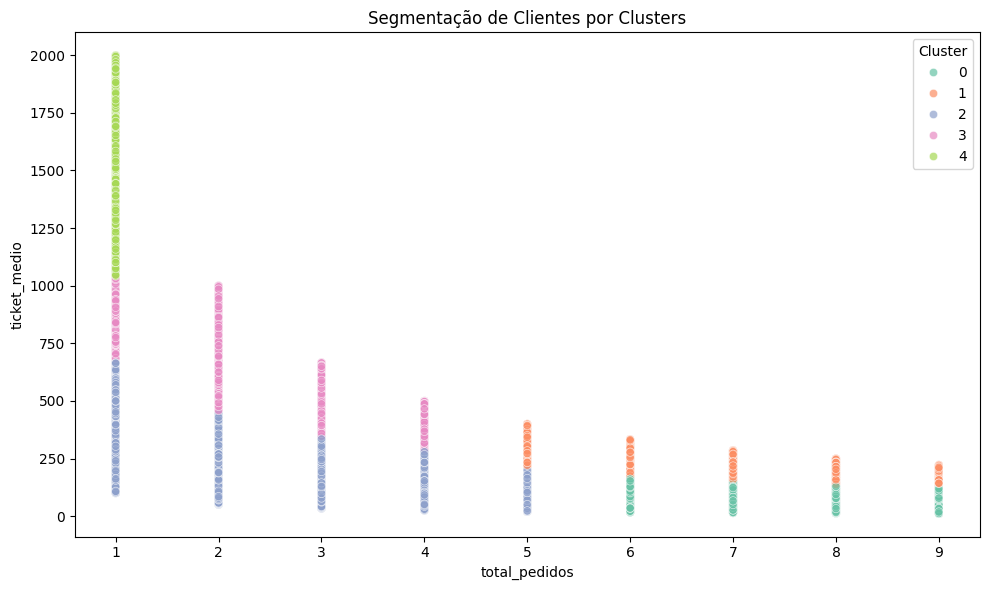

2026-03-02 18:02:57,785 - src.analysis - INFO - Visualization generated.


In [4]:
from src.analysis import analyze_clusters, visualize_clusters

numeric_cols = ['total_pedidos', 'total_gasto', 'ticket_medio', 'Cluster']
cluster_analysis = analyze_clusters(preprocessed_data[numeric_cols], cluster_labels)
visualize_clusters(preprocessed_data, cluster_labels)

# 5. Estratégias de marketing

Com base na análise, sugerimos estratégias de marketing adaptadas a cada segmento.

In [5]:
from src.marketing_strategies import MarketingStrategist

cluster_analysis = cluster_analysis.rename(columns={
    'ticket_medio': 'average_spending',
    'total_pedidos': 'loyalty'
})

if 'loyalty' not in cluster_analysis.columns:
    cluster_analysis['loyalty'] = 1

cols_needed = ['average_spending', 'loyalty']
cluster_analysis = cluster_analysis[cols_needed]
cluster_analysis_dict = cluster_analysis.to_dict(orient='index')

for k in cluster_analysis_dict:
    if 'frequency' not in cluster_analysis_dict[k]:
        cluster_analysis_dict[k]['frequency'] = 1

strategist = MarketingStrategist()
strategies = strategist.suggest_strategies(cluster_analysis_dict)
strategies


2026-03-02 18:11:01,243 - src.marketing_strategies - INFO - Generating strategies for 5 clusters...
2026-03-02 18:11:01,244 - src.marketing_strategies - INFO - Marketing strategies formulated.


{0: 'Encourage repeat purchases through discounts and promotions.',
 1: 'Encourage repeat purchases through discounts and promotions.',
 2: 'Encourage repeat purchases through discounts and promotions.',
 3: 'Promote upselling and cross-selling opportunities.',
 4: 'Target with exclusive offers and loyalty programs.'}

# Conclusão

Neste notebook, segmentamos com sucesso os clientes em grupos, analisamos o seu comportamento e sugerimos estratégias de marketing específicas para cada segmento.